# Following splink's example, for the synthetic dataset

We follow the steps done in 

`https://moj-analytical-services.github.io/splink/demos/examples/duckdb/transactions.html`

while adapting the datasets for the synthetic dataset.

In [1]:
# Required dependencies
import pandas as pd
import numpy as np
import os
import sys
import yaml

from splink import DuckDBAPI, Linker, SettingsCreator, block_on


import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.parquet as pq

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8')
%matplotlib inline

# Notebook config helper, handles path config and package imports 
from notebook_helper import setup_notebook_environment
helper = setup_notebook_environment()

from em_pipeline.data_loader import (
    load_pair_dfs_from_paths,
    standardise_dt,
    plot_numerical_distribution
)
from em_pipeline.splink_helper import (
    build_api_with_con,
    get_blocking_rules,
    get_estimating_blocking_rules,
    get_numerical_comparison,
    get_datetime_comparison,
    get_category_comparison
)

In [2]:
NOTEBOOK_NAME = "splink_local_smallest"

MEM_LIMIT  = "24GB"
TEMP_DIR   = "/tmp"

# Column names used in the synthetic dataset
LEFT_ID_COL   = "local_source_id"      # appears in both df1 & df2 after loading
RIGHT_ID_COL  = "local_source_id"
UNIQUE_ID_COL = "row_id"                # we eventually attempt to build this for labelling.
GROUND_TRUTH_ID_COL = "latent_event_id"      # used for ground truths
CATEGORICAL_COL   = "categorical"
NUMERIC_COL       = "numerical_noisy"
DATETIME_COL      = "datetime_noisy"

# How strict we want the initial random‑match estimate to be
RECALL_FOR_PRIOR = 0.99   # same as the original notebook

In [3]:
dataset_a_path, dataset_b_path = helper.ensure_dataset_exists('smallest')

print(f"Dataset A path: {dataset_a_path}")
print(f"Dataset B path: {dataset_b_path}")


Dataset A path: /home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/notebooks/../data/smallest_dataset_a.parquet
Dataset B path: /home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/notebooks/../data/smallest_dataset_b.parquet


In [4]:
df1, df2 = load_pair_dfs_from_paths(dataset_a_path, dataset_b_path)

print(f"\nDataset A shape: {df1.shape}")
print(f"Dataset B shape: {df2.shape}")

print(f"\nDataset A columns: {list(df1.columns)}")
print(f"Dataset B columns: {list(df2.columns)}")


Dataset A shape: (1669, 6)
Dataset B shape: (2086, 6)

Dataset A columns: ['global_entity_id', 'local_source_id', 'categorical', 'numerical_noisy', 'datetime_noisy', 'latent_event_id']
Dataset B columns: ['global_entity_id', 'local_source_id', 'categorical', 'numerical_noisy', 'datetime_noisy', 'latent_event_id']


In [5]:
df1["row_id"] = "df1_" + df1.index.astype(str)
df2["row_id"] = "df2_" + df2.index.astype(str)
df1

,global_entity_id,local_source_id,categorical,numerical_noisy,datetime_noisy,latent_event_id,row_id
0,100051,DF1_100051,CAT_2,1549.11,2025-12-31 20:47:22.032547758,OVER_0,df1_0
1,100068,DF1_100068,CAT_4,725.30,2025-12-31 23:59:38.962020717,UNI_A_147,df1_1
2,100075,DF1_100075,CAT_4,356.41,2026-01-01 02:40:20.372498903,OVER_2,df1_2
3,100068,DF1_100068,CAT_3,1710.56,2026-01-01 05:05:58.177891854,UNI_A_148,df1_3
4,100007,DF1_100007,CAT_6,716.24,2026-01-01 06:52:24.998262806,UNI_A_149,df1_4
...,...,...,...,...,...,...,...
1664,100024,DF1_100024,CAT_5,518.77,2026-05-31 11:16:58.073592622,UNI_A_1664,df1_1664
1665,100005,DF1_100005,CAT_7,1715.73,2026-05-31 16:55:07.536510765,UNI_A_1665,df1_1665
1666,100020,DF1_100020,CAT_4,549.15,2026-05-31 18:37:17.209879152,UNI_A_1666,df1_1666
1667,100052,DF1_100052,CAT_4,557.59,2026-05-31 19:31:23.912624442,UNI_A_1667,df1_1667


### Basic EDA, processing

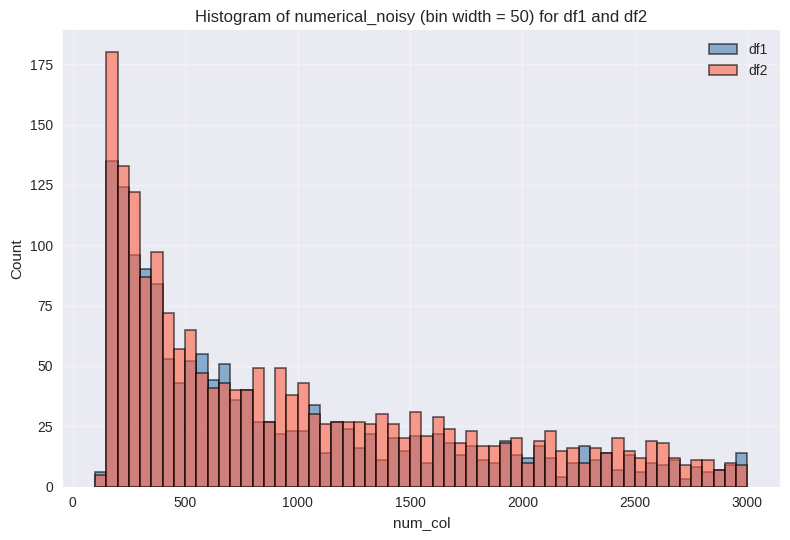

In [6]:
plot_numerical_distribution(df1, df2, "numerical_noisy")

In [7]:
# Basic preprocessing - we currently assume we do not have consistency in time across both DFs. 
# If this is no longer the case, just remove this line and update the datetime comparisons/blocking accordingly.
standardise_dt(df1, df2, DATETIME_COL)

Set datetime_noisy to date for both df1 and df2.


### We can take a look at the distributions of the data with profile_columns

In [8]:
from splink.exploratory import profile_columns

db_api = build_api_with_con(MEM_LIMIT, TEMP_DIR)

profile_columns(
    [df1, df2],
    db_api=db_api,
    column_expressions=[
        "categorical",
        "datetime_noisy",
        "numerical_noisy",
    ],
)

alt.VConcatChart(...)

### Splink's blocking analysis tool

We can use this to take a look at how effective our blocking is. Each increment introduces more unique pairs (w.r.t. previous blocking rules) into the total - the approach here is to get rid of pairs that we KNOW cannot be matches.

In [9]:
from splink.blocking_analysis import (
    cumulative_comparisons_to_be_scored_from_blocking_rules_chart
)

brs = get_blocking_rules()

cumulative_comparisons_to_be_scored_from_blocking_rules_chart(
    table_or_tables=[df1, df2],
    blocking_rules=brs,
    db_api=db_api,
    link_type="link_only",
    unique_id_column_name=UNIQUE_ID_COL
)

alt.Chart(...)

We've dropped the number of comparisons from somewhere north of 12 million pairs to roughly 8 million - a 30%+ reduction. Given we have better heuristics about pairs that are definitely not matches, we can further reduce this.

### Pulling comparisons, setting up splink for estimation

In [10]:
# We use the preset comparison levels for the artificial dataset, these can be found and tweaked at em_pipeline/comparisons.py
numerical_noisy_comparison = get_numerical_comparison(num_col=NUMERIC_COL)
datetime_noisy_comparison = get_datetime_comparison(dt_col=DATETIME_COL)
categorical_comparison = get_category_comparison(cat_col=CATEGORICAL_COL)

settings = SettingsCreator(
    link_type="link_only", 
    unique_id_column_name=UNIQUE_ID_COL,
    blocking_rules_to_generate_predictions=brs,
    max_iterations=50,
    comparisons=[
        numerical_noisy_comparison,
        categorical_comparison,
        datetime_noisy_comparison
    ],
    retain_intermediate_calculation_columns=True,
    additional_columns_to_retain=["local_source_id", "latent_event_id"],
)

linker = Linker(
    [df1, df2],
    settings,
    db_api=db_api
)

In [11]:
# "training" the linker - we first estimate an overall prior pi - basically the likelihood of a match.
# we do this by estimating it with a set of strict blockers that we know MUST be matches.

linker.training.estimate_probability_two_random_records_match(
    get_estimating_blocking_rules(), recall=0.9
)

Probability two random records match is estimated to be  6.1e-05.
This means that amongst all possible pairwise record comparisons, one in 16,405.13 are expected to match.  With 3,481,534 total possible comparisons, we expect a total of around 212.22 matching pairs


In [12]:
# Making estimates for u values.

linker.training.estimate_u_using_random_sampling(max_pairs=1e8)

----- Estimating u probabilities using random sampling -----

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - numerical_noisy (no m values are trained).
    - categorical (no m values are trained).
    - datetime_noisy (no m values are trained).


In [13]:
# We now estimate m values, we do this with a two-pass fixing one column and estimating for all columns BUT that one.
# In this case, we care about just a basic, loose set of blockers so that our EM has enough pairs to make estimations
# for various bins.

# Pass 1 - estimate parameters blocking on date.
linker.training.estimate_parameters_using_expectation_maximisation(
     """
        ABS(
            epoch(CAST(l.datetime_noisy AS TIMESTAMP)) - 
            epoch(CAST(r.datetime_noisy AS TIMESTAMP))
        ) <= 172800
    """
)

# Pass 2 - estimate parameters blocking on categorical
linker.training.estimate_parameters_using_expectation_maximisation(
    """
    (ABS(l.numerical_noisy - r.numerical_noisy) / NULLIF(l.numerical_noisy, 0)) <= 0.15
    """
)


----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:

        ABS(
            epoch(CAST(l.datetime_noisy AS TIMESTAMP)) - 
            epoch(CAST(r.datetime_noisy AS TIMESTAMP))
        ) <= 172800
    

Parameter estimates will be made for the following comparison(s):
    - numerical_noisy
    - categorical

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - datetime_noisy

Iteration 1: Largest change in params was -0.00869 in the m_probability of categorical, level `All other comparisons`
Iteration 2: Largest change in params was 0.00719 in the m_probability of categorical, level `Exact match on categorical`
Iteration 3: Largest change in params was 0.00592 in the m_probability of categorical, level `Exact match on categorical`
Iteration 4: Largest change in params was -0.00485 in the m_probability of categorical, level `All other comparisons`
Iteration 5: Largest cha

<EMTrainingSession, blocking on 
    (ABS(l.numerical_noisy - r.numerical_noisy) / NULLIF(l.numerical_noisy, 0)) <= 0.15
    , deactivating comparisons numerical_noisy>

In [14]:
# We can view the estimated match weights

linker.visualisations.match_weights_chart()

/home/local/KLASS/steven.zhu/miniconda3/envs/GlobalEM/lib/python3.11/site-packages/altair/vegalite/v6/api.py:4138: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  return _tp.from_dict(dct, validate=validate)


alt.VConcatChart(...)

In [15]:
df_predict = linker.inference.predict()
pd_predict = df_predict.as_pandas_dataframe()

Blocking time: 0.86 seconds
Predict time: 0.53 seconds


In [16]:
pd_predict

,match_weight,match_probability,source_dataset_l,source_dataset_r,row_id_l,row_id_r,numerical_noisy_l,numerical_noisy_r,gamma_numerical_noisy,bf_numerical_noisy,categorical_l,categorical_r,gamma_categorical,bf_categorical,datetime_noisy_l,datetime_noisy_r,gamma_datetime_noisy,bf_datetime_noisy,local_source_id_l,local_source_id_r,latent_event_id_l,latent_event_id_r,match_key
0,-18.411311,2.868415e-06,__splink__input_table_0,__splink__input_table_1,df1_195,df2_1062,NaN,803.89,-1,1.000000,CAT_6,CAT_6,1,9.965853,2026-01-19,2026-03-21,0,0.004722,DF1_100025,DF2_100016,UNI_A_320,UNIQ_B_2653,0
1,-27.724104,4.510381e-09,__splink__input_table_0,__splink__input_table_1,df1_300,df2_1063,1048.72,337.04,0,0.001572,CAT_3,CAT_3,1,9.965853,2026-01-29,2026-03-21,0,0.004722,DF1_100004,DF2_100070,UNI_A_415,UNIQ_B_2654,0
2,-27.724104,4.510381e-09,__splink__input_table_0,__splink__input_table_1,df1_128,df2_1064,550.26,1122.23,0,0.001572,CAT_0,CAT_0,1,9.965853,2026-01-13,2026-03-21,0,0.004722,DF1_100094,DF2_100064,UNI_A_259,UNIQ_B_2655,0
3,-24.842769,3.323391e-08,__splink__input_table_0,__splink__input_table_1,df1_300,df2_1066,1048.72,1232.39,2,0.011586,CAT_3,CAT_3,1,9.965853,2026-01-29,2026-03-21,0,0.004722,DF1_100004,DF2_100082,UNI_A_415,UNIQ_B_2657,0
4,-18.411311,2.868415e-06,__splink__input_table_0,__splink__input_table_1,df1_321,df2_1067,339.50,NaN,-1,1.000000,CAT_2,CAT_2,1,9.965853,2026-01-31,2026-03-21,0,0.004722,DF1_100086,DF2_100044,UNI_A_434,UNIQ_B_2658,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1394501,-31.268547,3.865713e-10,__splink__input_table_0,__splink__input_table_1,df1_1078,df2_1566,NaN,205.09,-1,1.000000,CAT_8,CAT_9,0,0.001343,2026-04-10,2026-04-28,0,0.004722,DF1_100079,DF2_100055,UNI_A_1128,UNIQ_B_3121,2
1394502,-31.268547,3.865713e-10,__splink__input_table_0,__splink__input_table_1,df1_1078,df2_1568,NaN,155.67,-1,1.000000,CAT_8,CAT_6,0,0.001343,2026-04-10,2026-04-28,0,0.004722,DF1_100079,DF2_100008,UNI_A_1128,UNIQ_B_3123,2
1394503,-31.268547,3.865713e-10,__splink__input_table_0,__splink__input_table_1,df1_1078,df2_1570,NaN,933.36,-1,1.000000,CAT_8,CAT_7,0,0.001343,2026-04-10,2026-04-28,0,0.004722,DF1_100079,DF2_100013,UNI_A_1128,UNIQ_B_3125,2
1394504,-31.268547,3.865713e-10,__splink__input_table_0,__splink__input_table_1,df1_1078,df2_1571,NaN,332.13,-1,1.000000,CAT_8,CAT_0,0,0.001343,2026-04-10,2026-04-28,0,0.004722,DF1_100079,DF2_100019,UNI_A_1128,UNIQ_B_3126,2


In [17]:
# 2. Flag true matches inside the scored pool
pd_predict["is_true_match"] = (
    pd_predict["latent_event_id_l"] == pd_predict["latent_event_id_r"]
).astype(int)

# 3. Get the total true match ceiling via a fast 1-to-1 merge count
# This catches matches that were blocked, ensuring Recall remains accurate
total_true_matches = (
    df1[["latent_event_id"]]
    .merge(df2[["latent_event_id"]], on="latent_event_id")
    .shape[0]
)

# 4. Generate metrics across thresholds (0.0 to 1.0)
thresholds = np.linspace(0.0, 1.0, 101)
curve_data = []

for t in thresholds:
    # Filter predictions at current probability threshold
    pred_positive = pd_predict["match_probability"] >= t

    tp = ((pred_positive) & (pd_predict["is_true_match"] == 1)).sum()
    fp = ((pred_positive) & (pd_predict["is_true_match"] == 0)).sum()

    # Calculate metrics with standard division-by-zero safeguards
    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    recall = tp / total_true_matches if total_true_matches > 0 else 0.0
    f1 = (
        2 * (precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    curve_data.append(
        {"threshold": t, "precision": precision, "recall": recall, "f1_score": f1}
    )

df_curve = pd.DataFrame(curve_data)

print("--- CORE PERFORMANCE THRESHOLDS ---")
print(df_curve.head(20))


--- CORE PERFORMANCE THRESHOLDS ---
    threshold  precision    recall  f1_score
0        0.00   0.000105  1.000000  0.000211
1        0.01   0.217213  0.721088  0.333858
2        0.02   0.217213  0.721088  0.333858
3        0.03   0.217213  0.721088  0.333858
4        0.04   0.217213  0.721088  0.333858
5        0.05   0.217213  0.721088  0.333858
6        0.06   0.217213  0.721088  0.333858
7        0.07   0.217213  0.721088  0.333858
8        0.08   0.217213  0.721088  0.333858
9        0.09   0.444444  0.625850  0.519774
10       0.10   0.444444  0.625850  0.519774
11       0.11   0.444444  0.625850  0.519774
12       0.12   0.444444  0.625850  0.519774
13       0.13   0.444444  0.625850  0.519774
14       0.14   0.444444  0.625850  0.519774
15       0.15   0.444444  0.625850  0.519774
16       0.16   0.444444  0.625850  0.519774
17       0.17   0.444444  0.625850  0.519774
18       0.18   0.444444  0.625850  0.519774
19       0.19   0.444444  0.625850  0.519774


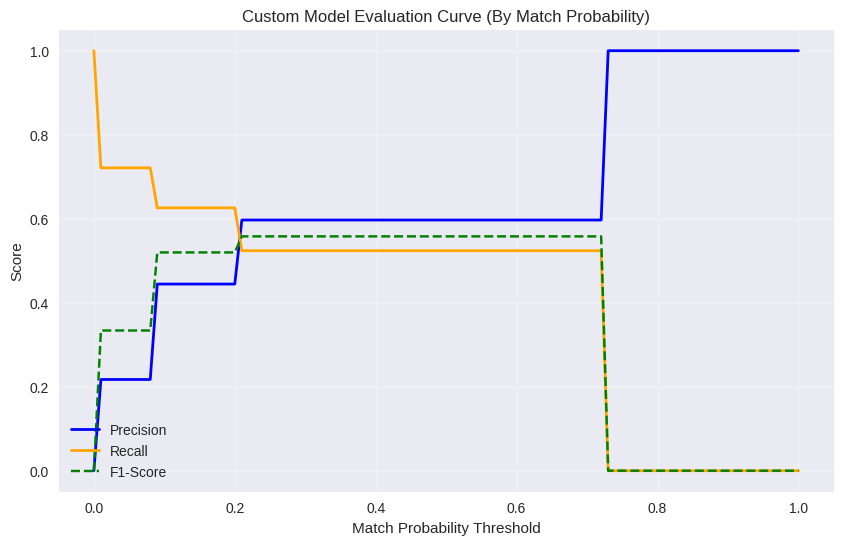

In [18]:
from notebook_helper import save_chart

plt.figure(figsize=(10, 6))
plt.plot(df_curve["threshold"], df_curve["precision"], label="Precision", color="blue", lw=2)
plt.plot(df_curve["threshold"], df_curve["recall"], label="Recall", color="orange", lw=2)
plt.plot(df_curve["threshold"], df_curve["f1_score"], label="F1-Score", color="green", linestyle="--")

plt.title("Custom Model Evaluation Curve (By Match Probability)")
plt.xlabel("Match Probability Threshold")
plt.ylabel("Score")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

# Save it using our helper:
save_chart(plt.gcf(), NOTEBOOK_NAME, "threshold_curve")
plt.show()
plt.close()

### Reviewing our results

In [19]:
linker.evaluation.accuracy_analysis_from_labels_column(
    GROUND_TRUTH_ID_COL, 
    output_type="threshold_selection",
    add_metrics=["f1", "accuracy"]
)

Blocking time: 0.85 seconds
Predict time: 0.65 seconds


alt.HConcatChart(...)

In [20]:
linker.evaluation.unlinkables_chart()

alt.LayerChart(...)

In [21]:
from notebook_helper import get_savable_visualisations

viz = get_savable_visualisations(NOTEBOOK_NAME, linker)
viz.match_weights_chart().save_image("match_weights_chart")
viz.unlinkables_chart().save_image("unlinkables_chart")

/home/local/KLASS/steven.zhu/miniconda3/envs/GlobalEM/lib/python3.11/site-packages/altair/vegalite/v6/api.py:4138: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  return _tp.from_dict(dct, validate=validate)


'/home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/notebooks/images/splink_local_smallest/unlinkables_chart.png'

## We notice that when we have less discriminatory fields, our results are less spectacular - let's evaluate what might be happening.

In [22]:
linker.visualisations.match_weights_chart()

alt.VConcatChart(...)

A lot of the comparisons are generally dragged massively down
This could be due to the blocking/comparison methods we are using - but since we don't actually care
about the actual value, but more of the overall ranking, we just review our false positives and false negs.

In [23]:
# Select the columns you want to visually inspect
inspect_cols = [
    "match_probability", 
    "latent_event_id_l", "latent_event_id_r", 
    "categorical_l", "categorical_r", 
    "numerical_noisy_l", "numerical_noisy_r",
    "datetime_noisy_l", "datetime_noisy_r"
]

# False positives
fp_examples = pd_predict[pd_predict["is_true_match"] == 0].sort_values(
    by="match_probability", ascending=False
)

fp_examples.head(20)

,match_weight,match_probability,source_dataset_l,source_dataset_r,row_id_l,row_id_r,numerical_noisy_l,numerical_noisy_r,gamma_numerical_noisy,bf_numerical_noisy,categorical_l,categorical_r,gamma_categorical,bf_categorical,datetime_noisy_l,datetime_noisy_r,gamma_datetime_noisy,bf_datetime_noisy,local_source_id_l,local_source_id_r,latent_event_id_l,latent_event_id_r,match_key,is_true_match
1059368,1.404067,0.725762,__splink__input_table_0,__splink__input_table_1,df1_1542,df2_1936,525.63,538.91,4,29.543322,CAT_4,CAT_4,1,9.965853,2026-05-22,2026-05-22,3,147.45039,DF1_100024,DF2_100008,UNI_A_1549,UNIQ_B_3464,0,0
1074888,1.404067,0.725762,__splink__input_table_0,__splink__input_table_1,df1_1438,df2_1787,790.06,797.60,4,29.543322,CAT_7,CAT_7,1,9.965853,2026-05-11,2026-05-11,3,147.45039,DF1_100010,DF2_100062,UNI_A_1457,UNIQ_B_3328,0,0
1090465,1.404067,0.725762,__splink__input_table_0,__splink__input_table_1,df1_1359,df2_1696,254.70,247.42,4,29.543322,CAT_7,CAT_7,1,9.965853,2026-05-05,2026-05-05,3,147.45039,DF1_100017,DF2_100019,UNI_A_1386,UNIQ_B_3245,0,0
1566,1.404067,0.725762,__splink__input_table_0,__splink__input_table_1,df1_520,df2_650,221.29,225.16,4,29.543322,CAT_4,CAT_4,1,9.965853,2026-02-19,2026-02-19,3,147.45039,DF1_100029,DF1_100051,UNI_A_614,OVER_52,0,0
1100181,1.404067,0.725762,__splink__input_table_0,__splink__input_table_1,df1_1322,df2_1620,1424.62,1497.26,4,29.543322,CAT_9,CAT_9,1,9.965853,2026-04-30,2026-04-30,3,147.45039,DF1_100021,DF2_100048,UNI_A_1353,UNIQ_B_3173,0,0
819158,1.404067,0.725762,__splink__input_table_0,__splink__input_table_1,df1_877,df2_1108,354.93,368.12,4,29.543322,CAT_7,CAT_7,1,9.965853,2026-03-24,2026-03-24,3,147.45039,DF1_100089,DF2_100035,UNI_A_945,UNIQ_B_2698,0,0
895057,1.404067,0.725762,__splink__input_table_0,__splink__input_table_1,df1_499,df2_622,432.52,422.93,4,29.543322,CAT_1,CAT_1,1,9.965853,2026-02-18,2026-02-18,3,147.45039,DF1_100074,DF2_100077,UNI_A_598,UNIQ_B_2242,0,0
840377,1.404067,0.725762,__splink__input_table_0,__splink__input_table_1,df1_626,df2_772,166.87,173.75,4,29.543322,CAT_8,CAT_8,1,9.965853,2026-03-01,2026-03-01,3,147.45039,DF1_100037,DF2_100030,UNI_A_715,UNIQ_B_2381,0,0
1024210,1.404067,0.725762,__splink__input_table_0,__splink__input_table_1,df1_1649,df2_2025,413.80,398.95,4,29.543322,CAT_1,CAT_1,1,9.965853,2026-05-29,2026-05-29,3,147.45039,DF1_100059,DF2_100048,UNI_A_1651,UNIQ_B_3551,0,0
1121454,1.404067,0.725762,__splink__input_table_0,__splink__input_table_1,df1_1089,df2_1347,1794.54,1844.95,4,29.543322,CAT_0,CAT_0,1,9.965853,2026-04-11,2026-04-11,3,147.45039,DF1_100086,DF2_100061,UNI_A_1139,UNIQ_B_2918,0,0


In [24]:
# False negatives
fn_examples = pd_predict[pd_predict["is_true_match"] == 1].sort_values(
    by="match_probability", ascending=True
)

fn_examples.head(20)

,match_weight,match_probability,source_dataset_l,source_dataset_r,row_id_l,row_id_r,numerical_noisy_l,numerical_noisy_r,gamma_numerical_noisy,bf_numerical_noisy,categorical_l,categorical_r,gamma_categorical,bf_categorical,datetime_noisy_l,datetime_noisy_r,gamma_datetime_noisy,bf_datetime_noisy,local_source_id_l,local_source_id_r,latent_event_id_l,latent_event_id_r,match_key,is_true_match
622658,-15.026298,0.000030,__splink__input_table_0,__splink__input_table_1,df1_175,df2_246,NaN,NaN,-1,1.000000,None,None,-1,1.000000,2026-01-18,2026-01-17,2,0.491572,DF1_100051,DF1_100051,OVER_20,OVER_20,2,1
1219342,-15.026298,0.000030,__splink__input_table_0,__splink__input_table_1,df1_32,df2_45,NaN,NaN,-1,1.000000,None,None,-1,1.000000,2026-01-03,2026-01-04,2,0.491572,DF1_100075,DF1_100075,OVER_8,OVER_8,2,1
51131,-11.709305,0.000299,__splink__input_table_0,__splink__input_table_1,df1_122,df2_174,NaN,NaN,-1,1.000000,CAT_9,CAT_9,1,9.965853,2026-01-12,2026-01-13,2,0.491572,DF1_100075,DF1_100075,OVER_15,OVER_15,0,1
7224,-11.709305,0.000299,__splink__input_table_0,__splink__input_table_1,df1_326,df2_425,NaN,NaN,-1,1.000000,CAT_7,CAT_7,1,9.965853,2026-02-01,2026-01-31,2,0.491572,DF1_100087,DF1_100087,OVER_34,OVER_34,0,1
1068985,-11.709305,0.000299,__splink__input_table_0,__splink__input_table_1,df1_1416,df2_1758,NaN,NaN,-1,1.000000,CAT_3,CAT_3,1,9.965853,2026-05-10,2026-05-09,2,0.491572,DF1_100075,DF1_100075,OVER_124,OVER_124,0,1
881067,-11.709305,0.000299,__splink__input_table_0,__splink__input_table_1,df1_234,df2_325,NaN,464.82,-1,1.000000,CAT_0,CAT_0,1,9.965853,2026-01-24,2026-01-23,2,0.491572,DF1_100051,DF1_100051,OVER_26,OVER_26,0,1
1135033,-11.709305,0.000299,__splink__input_table_0,__splink__input_table_1,df1_995,df2_1210,NaN,196.09,-1,1.000000,CAT_6,CAT_6,1,9.965853,2026-04-02,2026-04-01,2,0.491572,DF1_100075,DF1_100075,OVER_91,OVER_91,0,1
343327,-10.141538,0.000885,__splink__input_table_0,__splink__input_table_1,df1_1006,df2_1243,2884.69,2885.89,4,29.543322,None,None,-1,1.000000,2026-04-02,2026-04-03,2,0.491572,DF1_100039,DF1_100039,OVER_92,OVER_92,1,1
671945,-10.141538,0.000885,__splink__input_table_0,__splink__input_table_1,df1_66,df2_62,406.37,395.83,4,29.543322,None,None,-1,1.000000,2026-01-06,2026-01-05,2,0.491572,DF1_100051,DF1_100051,OVER_11,OVER_11,1,1
66005,-10.141538,0.000885,__splink__input_table_0,__splink__input_table_1,df1_1655,df2_2064,1127.72,1131.51,4,29.543322,CAT_1,None,-1,1.000000,2026-05-30,2026-05-31,2,0.491572,DF1_100075,DF1_100075,OVER_146,OVER_146,1,1


We see that most of the results make sense - one minor unresolved issue is the discriminatory factor
that numerical gives - intuitively it should make sense that the numerical comparison should provide
larger match weights. 

However, considering a missingness of 5% on both ends - it translates to ~10% missingness in either 
columns - which also means 10% of our actual truths are immediately uncapturable.

We also notice that the effect of the datetime shift is rather large.

## Moving to aggregation

In [25]:
from notebook_helper import (
    aggregate_entity_pair_matched_pairs,
    compute_source_sizes,
    calculate_match_density,
    calculate_weighted_jaccard,
    calculate_weighted_overlap,
    calculate_score_prob_ratio,
    second_layer_splink_evaluation,
    save_score_distribution_plot,
    save_precision_recall_curve,
    get_savable_visualisations
)

U_BASE = linker._settings_obj._probability_two_random_records_match

aggregated_df = aggregate_entity_pair_matched_pairs(
    pd_predict,
    id_columns=['local_source_id_l', 'local_source_id_r']
)

print("Aggregated entity-pair DataFrame shape:", aggregated_df.shape)
print("\nColumns:", list(aggregated_df.columns))
print("\nFirst 5 rows:")
display(aggregated_df.head())

Aggregated entity-pair DataFrame shape: (2500, 8)

Columns: ['local_source_id_l', 'local_source_id_r', 'sum_p', 'max_w', 'observed_edges', 'top_3_mean_w', 'score_noisy_or', 'score_softmax_p']

First 5 rows:


/home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/helpers/entity_resolution_aggregation.py:247: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(apply_agg_functions)


,local_source_id_l,local_source_id_r,sum_p,max_w,observed_edges,top_3_mean_w,score_noisy_or,score_softmax_p
0,DF1_100000,DF1_100039,0.000175,-12.793486,122,-15.638774,0.000175,0.000001
1,DF1_100000,DF1_100051,0.000209,-13.526550,93,-14.026466,0.000209,0.000002
2,DF1_100000,DF1_100073,0.000093,-13.526550,69,-16.783057,0.000093,0.000001
3,DF1_100000,DF1_100075,0.000230,-13.526550,164,-14.463676,0.000230,0.000001
4,DF1_100000,DF1_100087,0.000537,-11.453169,80,-12.835423,0.000537,0.000007


In [26]:
source_sizes = compute_source_sizes(df1, df2, 'local_source_id')

def add_structural_metrics(row):
    # Get sizes for left and right entities
    size_l = source_sizes.get(row['local_source_id_l'], {'size_l': 0})['size_l']
    size_r = source_sizes.get(row['local_source_id_r'], {'size_r': 0})['size_r']
    
    # Match density
    row['match_density'] = calculate_match_density(
        row['sum_p'], size_l, size_r
    )
    # Weighted Jaccard
    row['weighted_jaccard'] = calculate_weighted_jaccard(
        row['sum_p'], size_l, size_r
    )
    # Weighted overlap
    row['weighted_overlap'] = calculate_weighted_overlap(
        row['sum_p'], size_l, size_r
    )
    # Score-probability expected ratio (requires u_base from your Splink model)
    # You can estimate u_base as the average match probability from the prior
    # or use the m/u probabilities from the linker; here we use a placeholder.
    # Replace u_base_estimate with your actual value from the linker training.
    u_base_estimate = U_BASE  # <-- UPDATE THIS with your linker's u probability
    row['score_prob_expected_ratio'] = calculate_score_prob_ratio(
        row['sum_p'], size_l, size_r, u_base_estimate
    )
    return row

aggregated_with_metrics = aggregated_df.apply(add_structural_metrics, axis=1)

print("\nAfter adding structural metrics:")
display(aggregated_with_metrics[['local_source_id_l', 'local_source_id_r',
                               'sum_p', 'match_density', 'weighted_jaccard',
                               'weighted_overlap', 'score_noisy_or', 'score_softmax_p' ,'score_prob_expected_ratio']].head())



After adding structural metrics:


,local_source_id_l,local_source_id_r,sum_p,match_density,weighted_jaccard,weighted_overlap,score_noisy_or,score_softmax_p,score_prob_expected_ratio
0,DF1_100000,DF1_100039,0.000175,6.064265e-07,0.000004,0.000019,0.000175,0.000001,-4.604680
1,DF1_100000,DF1_100051,0.000209,8.024335e-07,0.000006,0.000023,0.000209,0.000002,-4.325567
2,DF1_100000,DF1_100073,0.000093,5.154734e-07,0.000003,0.000010,0.000093,0.000001,-4.762202
3,DF1_100000,DF1_100075,0.000230,5.672949e-07,0.000004,0.000026,0.000230,0.000001,-4.672734
4,DF1_100000,DF1_100087,0.000537,2.843106e-06,0.000018,0.000060,0.000537,0.000007,-3.063491


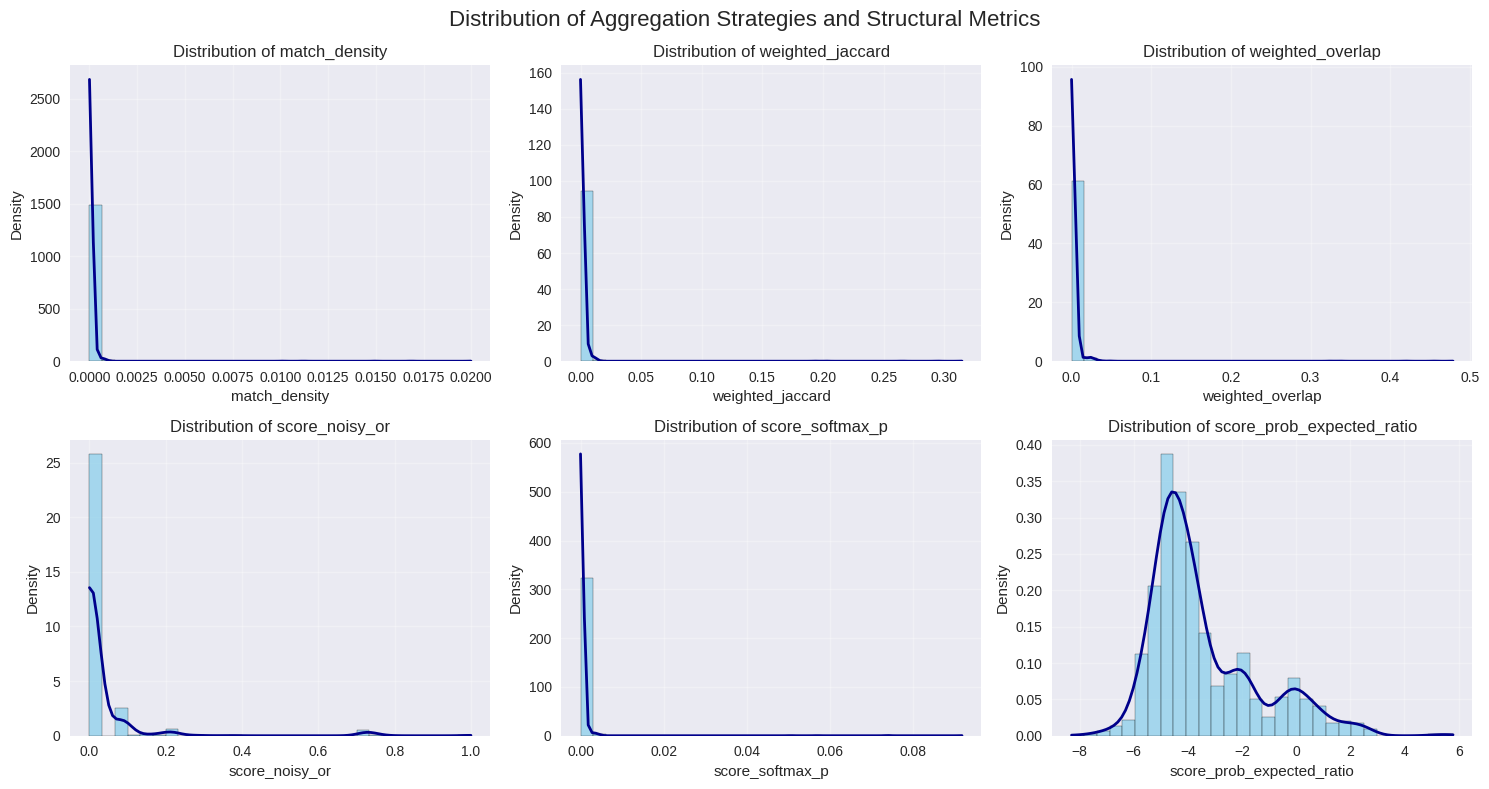

In [27]:
metrics_to_plot = [
    'match_density',
    'weighted_jaccard', 
    'weighted_overlap',
    'score_noisy_or',
    'score_softmax_p',
    'score_prob_expected_ratio'
]

# Create subplot layout
n_metrics = len(metrics_to_plot)
n_cols = min(3, n_metrics)
n_rows = (n_metrics + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
if n_metrics == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes.reshape(1, -1)

axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]

# Plot each metric
for idx, col in enumerate(metrics_to_plot):
    if idx >= len(axes_flat):
        break
    ax = axes_flat[idx]
    
    # Get data and remove NaNs
    data = aggregated_with_metrics[col].dropna()
    if len(data) == 0:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{col} (No Data)')
        continue
    
    # Create histogram with KDE
    ax.hist(data, bins=30, alpha=0.7, color='skyblue', edgecolor='black', density=True)
    
    # Add KDE if scipy is available
    try:
        from scipy import stats
        kde = stats.gaussian_kde(data)
        x_range = np.linspace(data.min(), data.max(), 100)
        ax.plot(x_range, kde(x_range), 'darkblue', linewidth=2)
    except ImportError:
        pass  # Skip KDE if scipy not available
    
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(metrics_to_plot), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Distribution of Aggregation Strategies and Structural Metrics', fontsize=16)
plt.tight_layout()

# In notebook: show_and_save_fig(fig, "splink_local_demo", "combined_aggregation_metrics_distribution")
plt.show()  # For script execution

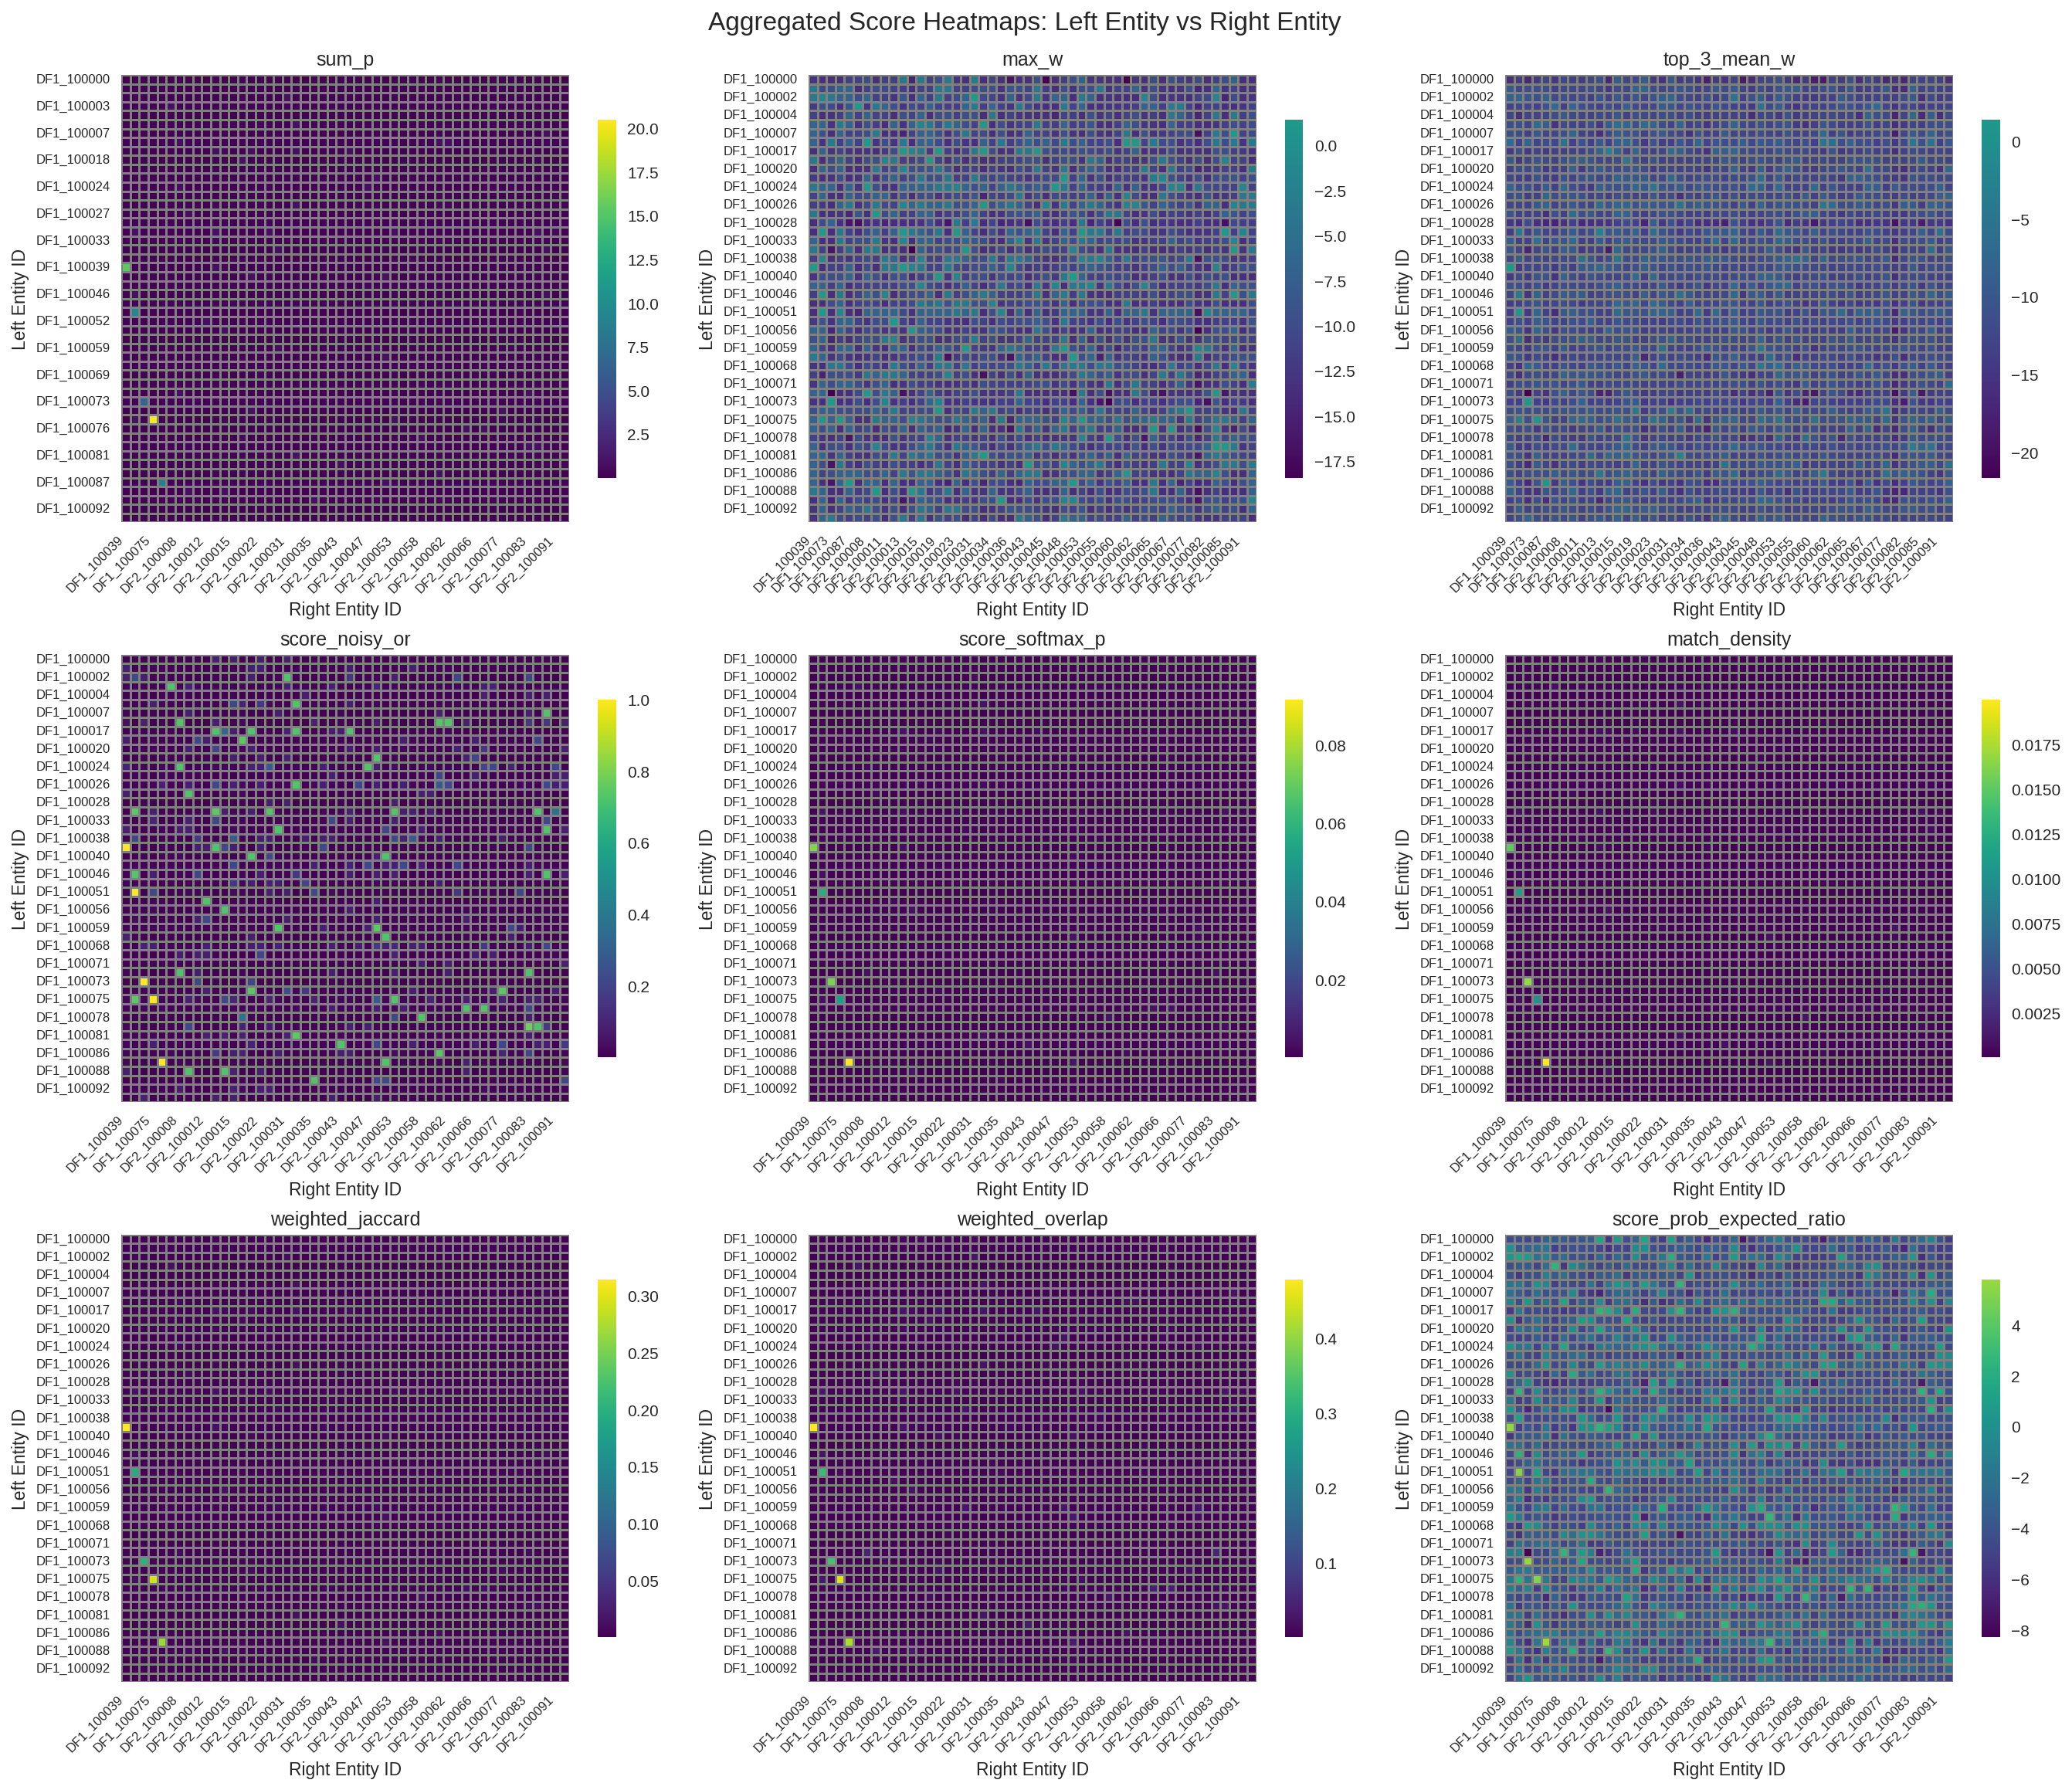

Figure saved to: /home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/notebooks/images/splink_local_smallest/aggregation_score_heatmaps.png


In [29]:
from helpers.visualization_helper import plot_aggregation_heatmaps, plot_threshold_evaluation

# Generate combined heatmap and precision-recall curves
plot_aggregation_heatmaps(
    aggregated_df=aggregated_with_metrics,  # or your aggregated dataframe
    score_columns=[
        'sum_p', 'max_w', 'top_3_mean_w', 
        'score_noisy_or', 'score_softmax_p',
        'match_density', 'weighted_jaccard', 
        'weighted_overlap', 'score_prob_expected_ratio'
    ],
    notebook_dir=NOTEBOOK_NAME
)

Computing entity-level ground truth for threshold evaluation...
Found 5 true entity pairs out of 2500 total pairs (0.20%)


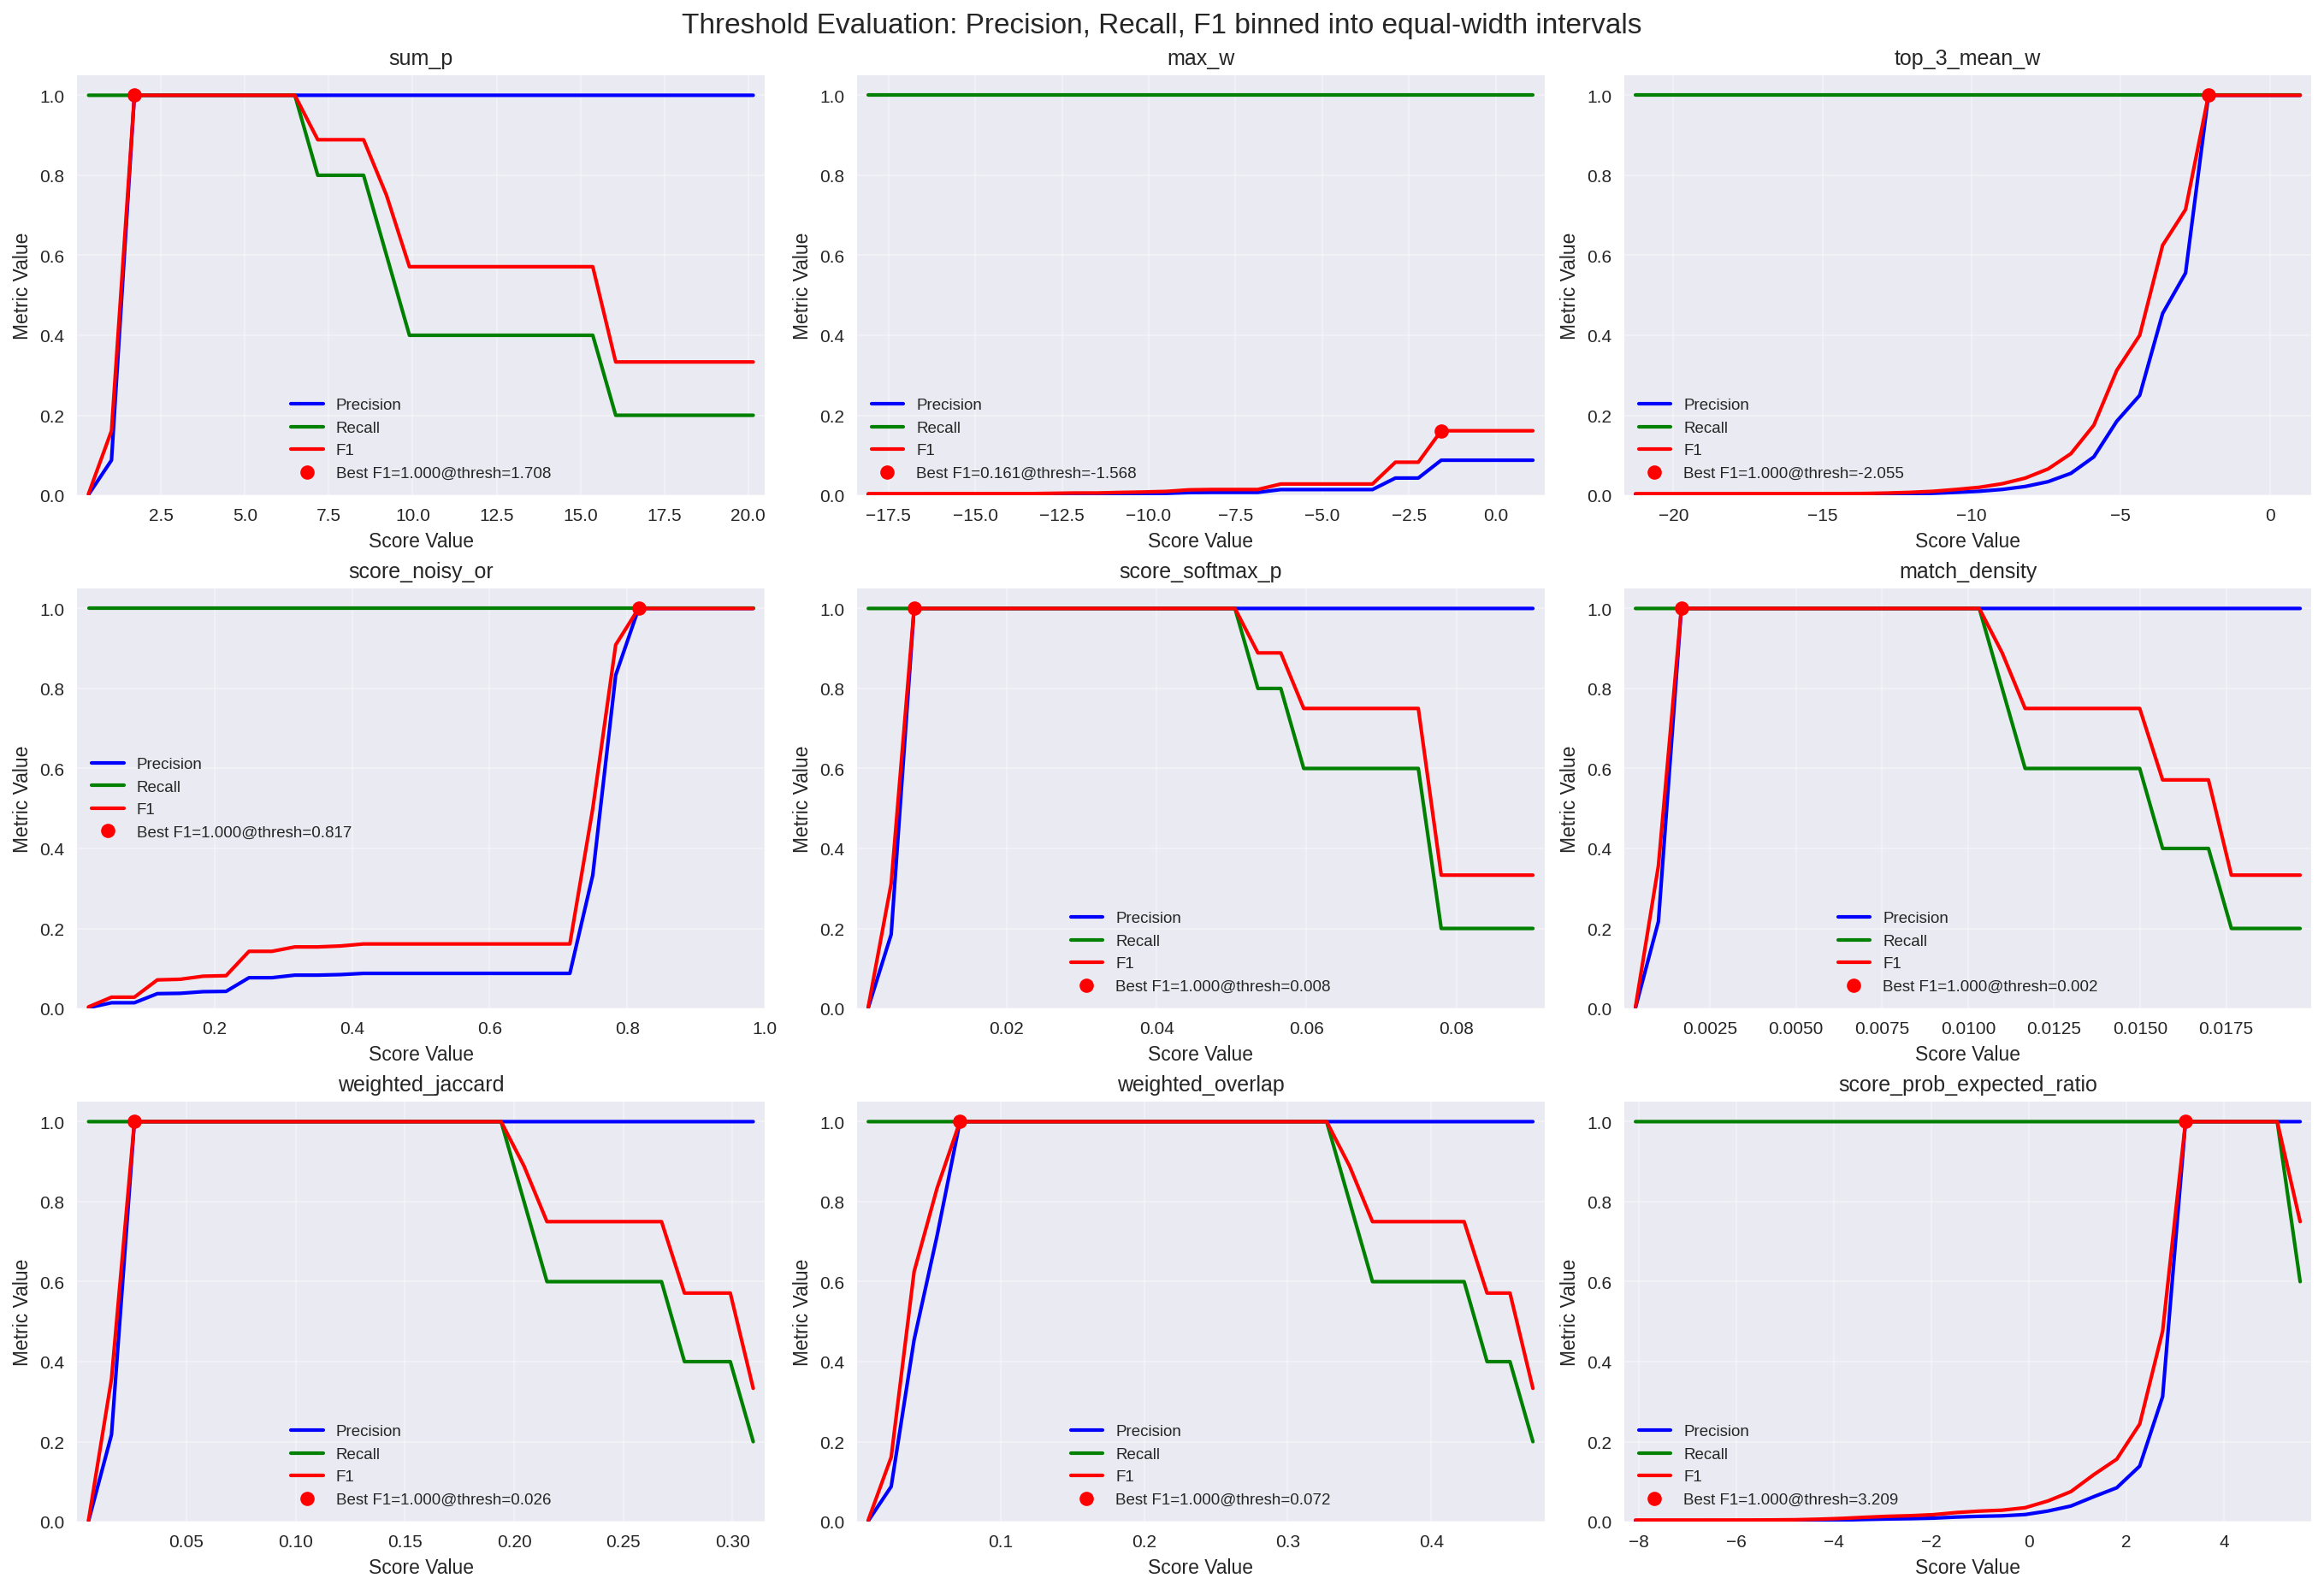

Figure saved to: /home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/notebooks/images/splink_local_smallest/threshold_evaluation_binned.png


In [30]:
plot_threshold_evaluation(
    aggregated_df=aggregated_with_metrics,
    df1=df1,
    df2=df2,
    score_columns=[
        'sum_p', 'max_w', 'top_3_mean_w', 
        'score_noisy_or', 'score_softmax_p',
        'match_density', 'weighted_jaccard', 
        'weighted_overlap', 'score_prob_expected_ratio'
    ],
    notebook_dir=NOTEBOOK_NAME,
    bins=30  # 30 bins as requeste
)